In [46]:
import similaritymeasures
import numpy as np
from scipy.integrate import simpson
from scipy.spatial.distance import euclidean
from scipy.interpolate import interp1d
import pandas as pd 
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['text.usetex'] = True  # Si tienes LaTeX instalado
mpl.rcParams['font.family'] = 'serif'

In [48]:
#--------------------------------- Estandarización
def estand(f):
    return (f-np.mean(f))/np.std(f)
#--------------------------------- DISTANCIAS L1 Y L2

def distancia_L2(f, g, x):
    f = estand(f)
    g = estand(g)
    return np.sqrt(simpson((f - g)**2, x))

def distancia_L1(f, g, x):
    f = estand(f)
    g = estand(g)
    return simpson(np.abs(f - g), x)

#----------------------------- CORRELACIÓN DE PEARSON FUNCIONAL

def pearson_funcional(f, g, x):
    f_mean = simpson(f, x) / (x[len(x)-1] - x[0])
    g_mean = simpson(g, x) / (x[len(x)-1] - x[0])
    numerator = simpson((f - f_mean) * (g - g_mean), x)
    denominator = np.sqrt(simpson((f - f_mean)**2, x) * simpson((g - g_mean)**2, x))
    return numerator / denominator

def ErrorRelativoPromedio(f,g,x):
    return np.abs(np.sum((f-g)/f)/len(x))

def DesviacionEstandar(f,g,x):
    return np.std((f-g)/f)

def FluxFactor(fluxes):
    maxflux = np.max(fluxes)
    minflux = np.min(fluxes)
    avgflux = np.mean(fluxes)
    stdflux = np.std(fluxes)


#    print("Max= ", maxflux," Min= ", minflux," Avg= ", avgflux," Std= ", stdflux)

    target_flux = 0.6
    fluxfactor = target_flux/avgflux
    return fluxes*fluxfactor

In [50]:
path_17 = rf"C:\Users\danyp\OneDrive\Escritorio\CosasPater\UNAL\TrabajoGradoAlejandro\Results\PhotonRings\LightCurve_PhotonRings_datas_dx0.1_dt0.6103515625_dtM1.220703125_a0.94_i17_inoisy_n0.4_i0.94_ft5000_spatial512_snap8192.csv"
path_60 = rf"C:\Users\danyp\OneDrive\Escritorio\CosasPater\UNAL\TrabajoGradoAlejandro\Results\PhotonRings\LightCurve_PhotonRings_datas_dx0.1_dt0.6103515625_dtM1.220703125_a0.94_i60_inoisy_n0.4_i0.94_ft5000_spatial512_snap8192.csv"

data_17 = pd.read_csv(path_17)
data_60 = pd.read_csv(path_60)

In [52]:
# Cargar tus datos (asumiendo que están en un DataFrame llamado df)
# df = pd.read_csv('tu_archivo.csv')  # Ajusta según cómo cargues tus datos

# Extraer el tiempo (variable x)
x = data_17['Time'].values
df = data_17.copy()

# Definir las categorías a comparar
categorias = [
    ('SlowLight n=0', 'FastLight n=0'),
    ('SlowLight n=0 + n=1', 'FastLight n=0 + n=1'),
    ('SlowLight Total', 'FastLight Total')
]

# Lista para almacenar resultados
resultados = []

for slow_col, fast_col in categorias:
    f = df[slow_col].values
    g = df[fast_col].values
    
    # Calcular métricas
    l2_dist = distancia_L2(f, g, x)
    l1_dist = distancia_L1(f, g, x)
    pearson_corr = pearson_funcional(f, g, x)
    
    resultados.append({
        'Comparación': f'{slow_col} vs {fast_col}',
        'Distancia_L2': l2_dist,
        'Distancia_L1': l1_dist, 
        'Pearson_Funcional': pearson_corr
    })

# Crear DataFrame con los resultados
resultados_df = pd.DataFrame(resultados)

# Configurar pandas para mostrar más decimales
pd.set_option('display.float_format', '{:.6f}'.format)

# Devolver el DataFrame para su uso posterior
resultados_df

,Comparación,Distancia_L2,Distancia_L1,Pearson_Funcional
0,SlowLight n=0 vs FastLight n=0,8.184912,367.358531,0.993297
1,SlowLight n=0 + n=1 vs FastLight n=0 + n=1,6.810194,311.427882,0.995360
2,SlowLight Total vs FastLight Total,6.932450,317.224628,0.995191


In [54]:
#################Slow Light#########################

Total_17s = FluxFactor(data_17["SlowLight Total"])
Total_60s = FluxFactor(data_60["SlowLight Total"])

First_17s = FluxFactor(data_17["SlowLight n=0 + n=1"])
First_60s = FluxFactor(data_60["SlowLight n=0 + n=1"])

Cero_17s = FluxFactor(data_17["SlowLight n=0"])
Cero_60s = FluxFactor(data_60["SlowLight n=0"])

#################Fast Light#########################

Total_17f = FluxFactor(data_17["FastLight Total"])
Total_60f = FluxFactor(data_60["FastLight Total"])

First_17f = FluxFactor(data_17["FastLight n=0 + n=1"])
First_60f = FluxFactor(data_60["FastLight n=0 + n=1"])

Cero_17f = FluxFactor(data_17["FastLight n=0"])
Cero_60f = FluxFactor(data_60["FastLight n=0"])


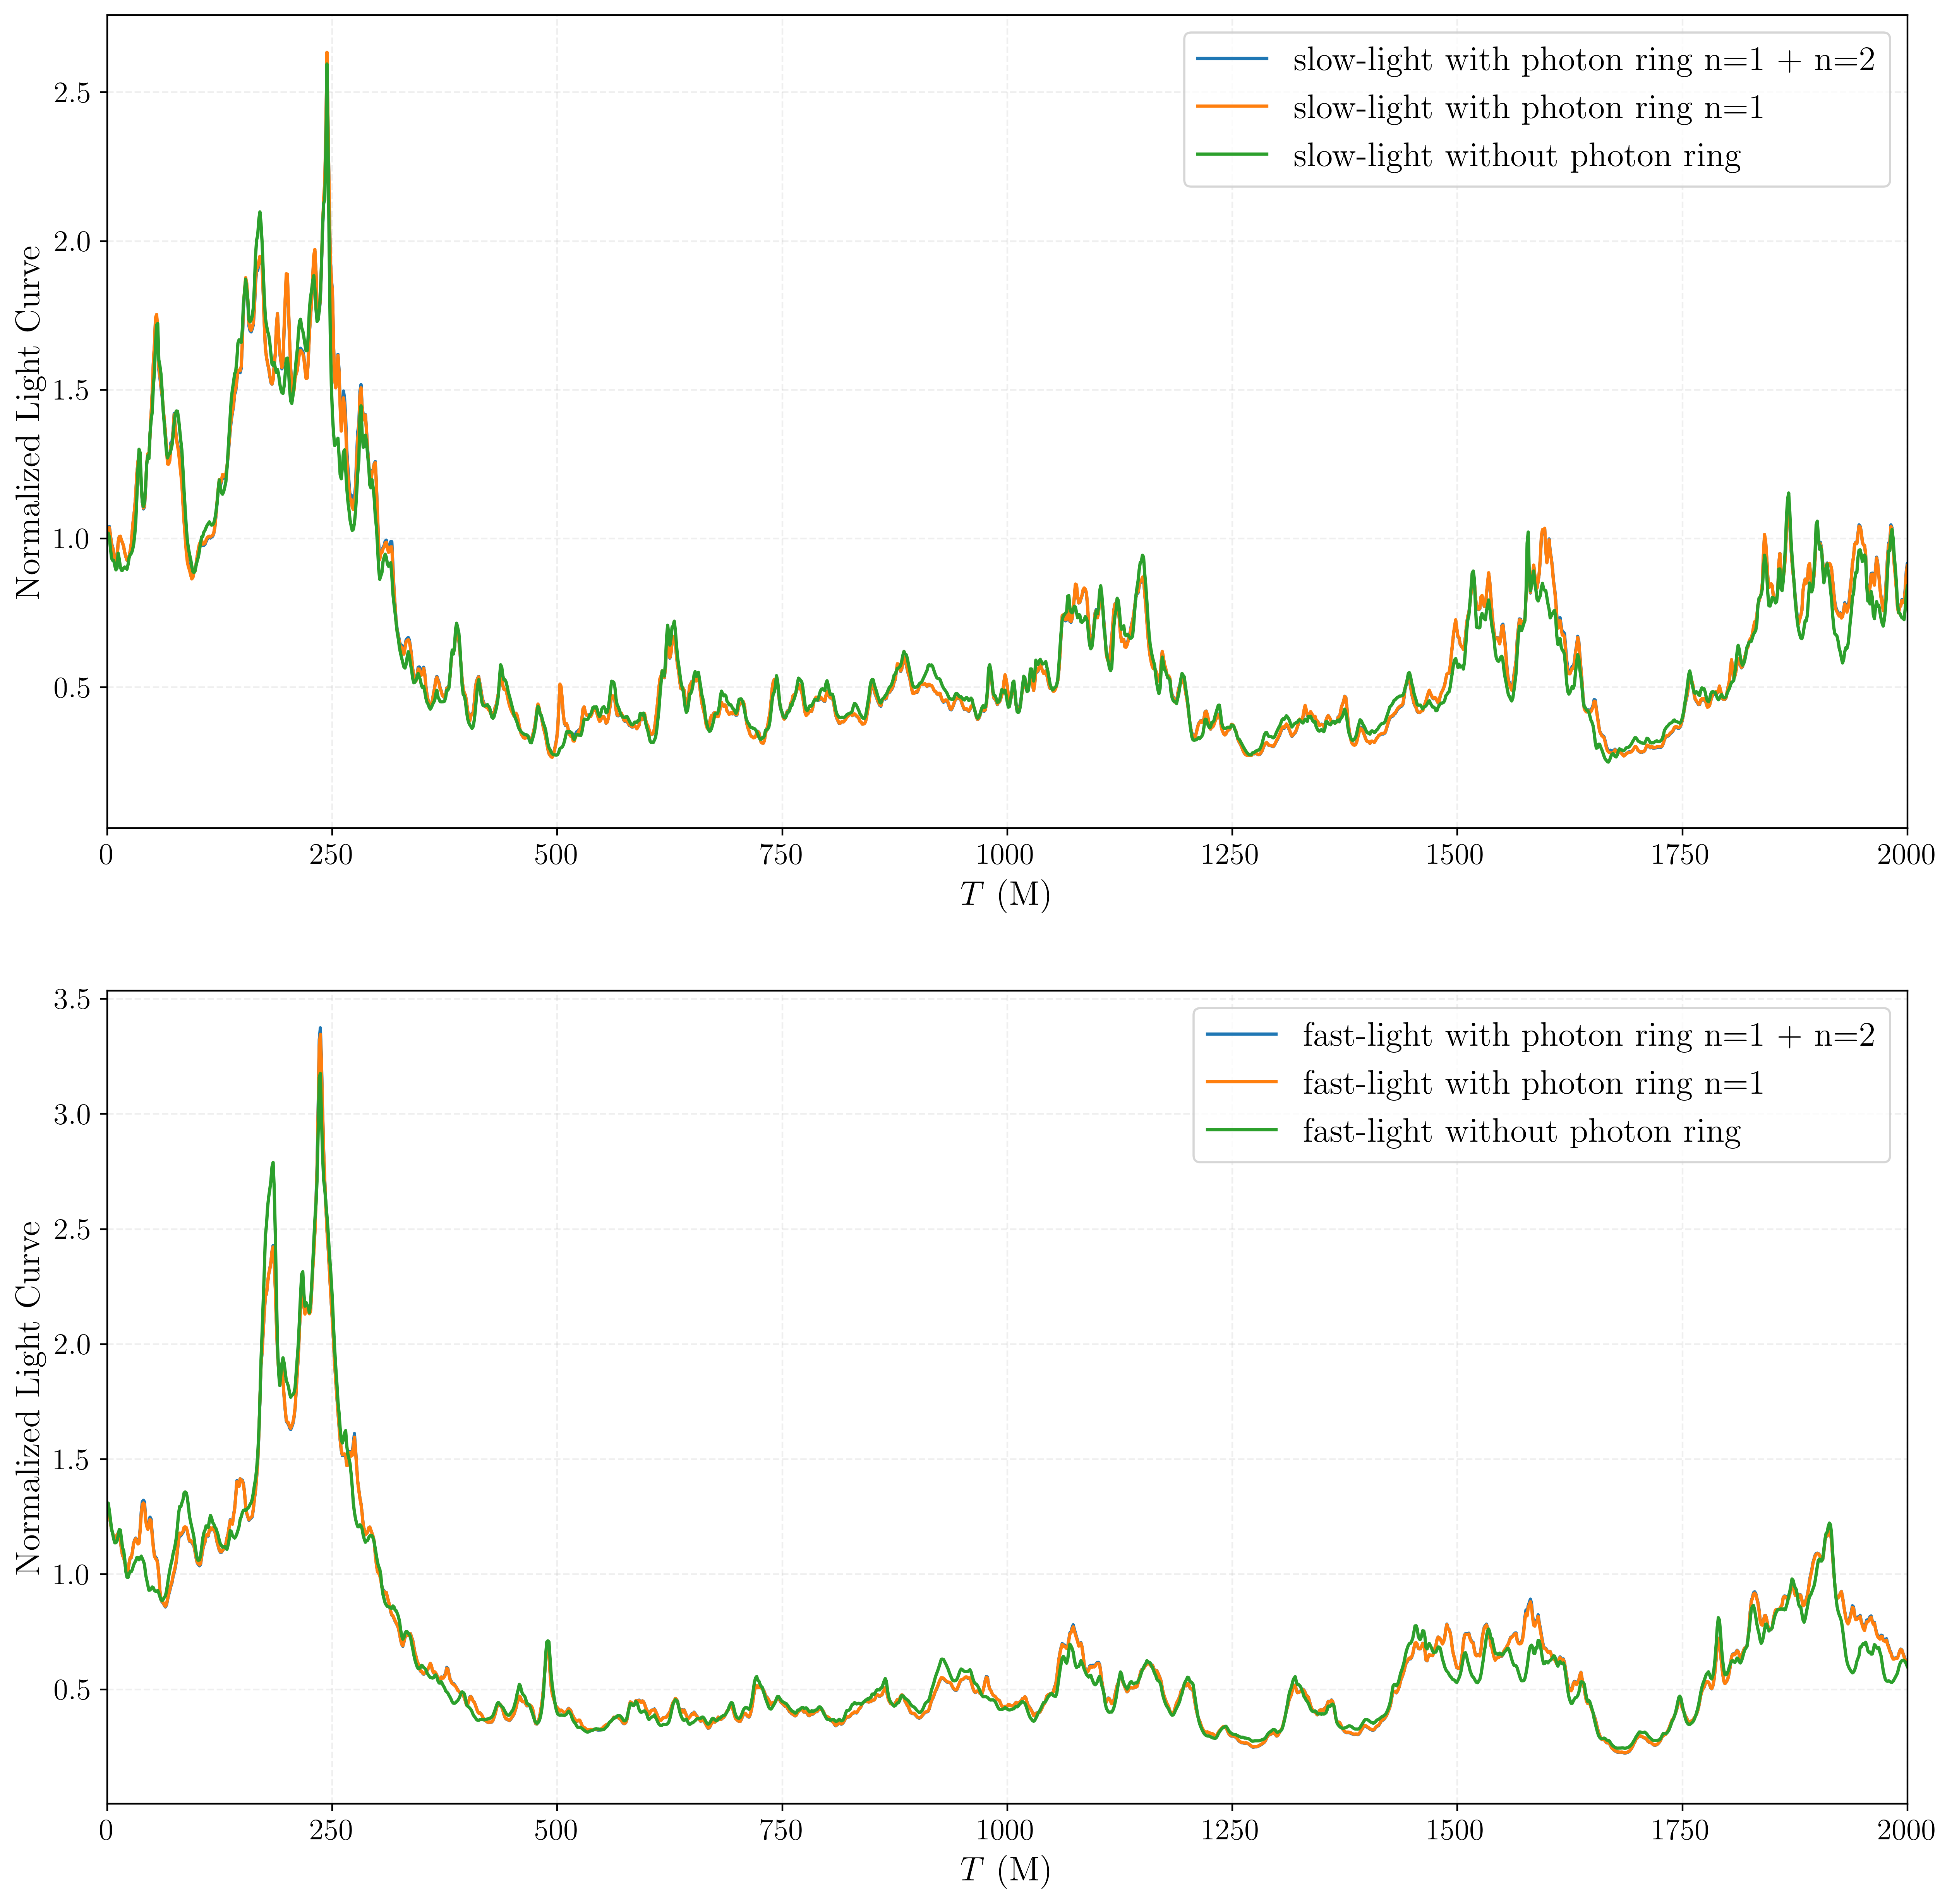

In [60]:

plt.figure(figsize=(15,15),dpi=400)

plt.subplot(2,1,1)
plt.plot(data_17["Time"],Total_60s,label="slow-light with photon ring n=1 + n=2")
plt.plot(data_17["Time"],First_60s,label="slow-light with photon ring n=1")
plt.plot(data_17["Time"],Cero_60s,label="slow-light without photon ring")
plt.xlim(0,2000)


plt.xlabel(r"$T$"+" "+"(M)",fontsize=16)
plt.ylabel(r"Normalized Light Curve",fontsize=16)
plt.grid(linestyle="--",alpha=0.2)
plt.tick_params(axis='both', labelsize=14)
plt.legend(fontsize=16)


plt.subplot(2,1,2)
plt.plot(data_17["Time"],Total_60f,label="fast-light with photon ring n=1 + n=2")
plt.plot(data_17["Time"],First_60f,label="fast-light with photon ring n=1")
plt.plot(data_17["Time"],Cero_60f,label="fast-light without photon ring")
plt.xlim(0,2000)

plt.xlabel(r"$T$"+" "+"(M)",fontsize=16)
plt.ylabel(r"Normalized Light Curve",fontsize=16)
plt.grid(linestyle="--",alpha=0.2)
plt.tick_params(axis='both', labelsize=14)
plt.legend(fontsize=16)

plt.savefig(rf"C:\Users\danyp\OneDrive\Escritorio\CosasPater\UNAL\TrabajoGradoAlejandro\Results\Imagenes\PhotonRing_Curve.png")
plt.show()



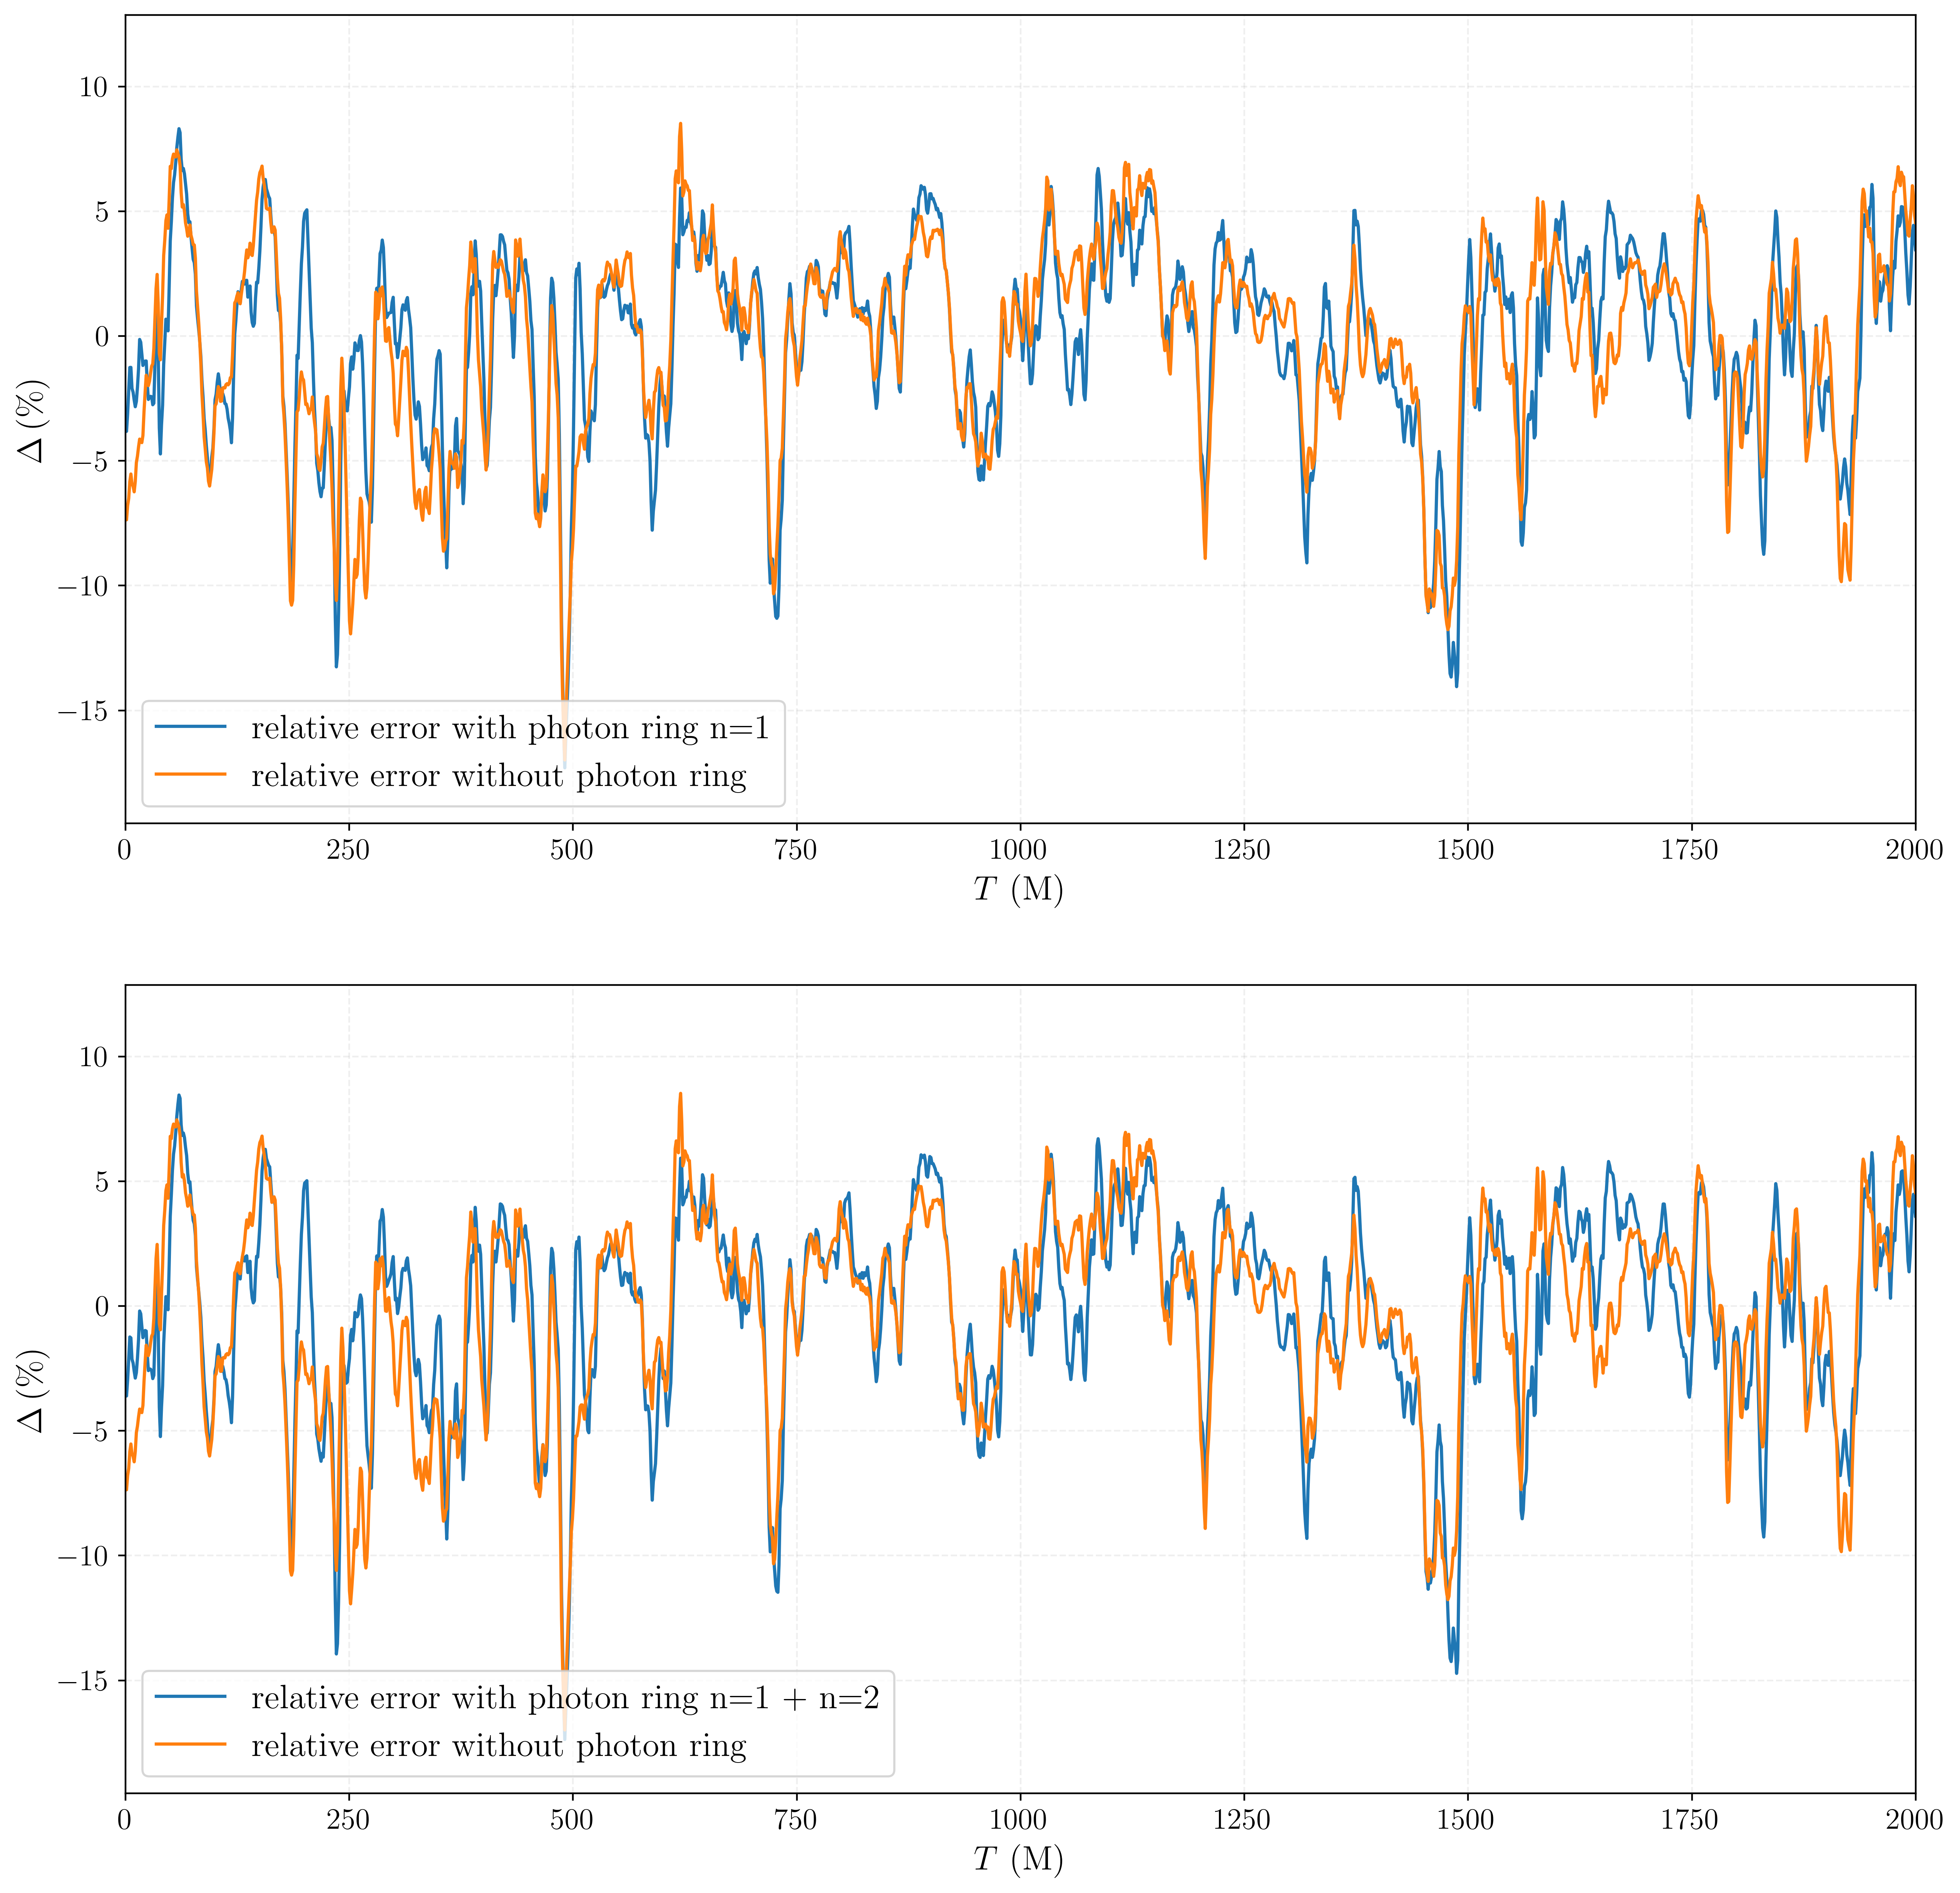

In [61]:
mpl.rcParams['text.usetex'] = True  # Si tienes LaTeX instalado
mpl.rcParams['font.family'] = 'serif'

plt.figure(figsize=(15,15),dpi=400)

plt.subplot(2,1,1)
plt.plot(data_17["Time"],(FluxFactor(data_17["SlowLight n=0 + n=1"])-FluxFactor(data_17["FastLight n=0 + n=1"]))*100/FluxFactor(data_60["SlowLight n=0 + n=1"]),label="relative error with photon ring n=1")
plt.plot(data_17["Time"],(FluxFactor(data_17["SlowLight n=0"])-FluxFactor(data_17["FastLight n=0"]))*100/FluxFactor(data_60["SlowLight n=0"]),label="relative error without photon ring")

plt.xlabel(r"$T$"+" "+"(M)",fontsize=16)
plt.ylabel(r"$\Delta\,(\%)$",fontsize=16)
plt.xlim(0,2000)
plt.grid(linestyle="--",alpha=0.2)
plt.tick_params(axis='both', labelsize=14)
plt.legend(fontsize=16,loc="lower left")

plt.subplot(2,1,2)
plt.plot(data_17["Time"],(FluxFactor(data_17["SlowLight Total"])-FluxFactor(data_17["FastLight Total"]))*100/FluxFactor(data_60["SlowLight Total"]),label="relative error with photon ring n=1 + n=2")
plt.plot(data_17["Time"],(FluxFactor(data_17["SlowLight n=0"])-FluxFactor(data_17["FastLight n=0"]))*100/FluxFactor(data_60["SlowLight n=0"]),label="relative error without photon ring")

plt.xlabel(r"$T$"+" "+"(M)",fontsize=16)
plt.ylabel(r"$\Delta\,(\%)$",fontsize=16)
plt.xlim(0,2000)
plt.grid(linestyle="--",alpha=0.2)
plt.tick_params(axis='both', labelsize=14)
plt.legend(fontsize=16,loc="lower left")
plt.savefig(rf"C:\Users\danyp\OneDrive\Escritorio\CosasPater\UNAL\TrabajoGradoAlejandro\Results\Imagenes\PhotonRing_Error.png")
plt.show()
